# Day 6: Advanced Analytics & Risk Metrics
This notebook generates the VaR/CVaR report and Rolling Sharpe chart.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths
base_dir = Path('..').resolve()
data_dir = base_dir / 'data' / 'processed'
reports_dir = base_dir / 'reports'


In [7]:
# Task 1: Historical VaR (95%) and CVaR
print("Loading NAV data...")
nav_df = pd.read_csv(data_dir / 'clean_nav.csv', parse_dates=['date'])
nav_df = nav_df.sort_values(by=['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()
returns_df = nav_df.dropna(subset=['daily_return'])

results = []
for amfi_code, group in returns_df.groupby('amfi_code'):
    returns = group['daily_return'].values
    if len(returns) < 30: continue
    
    var_95 = np.percentile(returns, 5)
    worst_returns = returns[returns <= var_95]
    cvar = worst_returns.mean()
    
    results.append({'amfi_code': amfi_code, 'VaR_95': var_95, 'CVaR': cvar})

metrics_df = pd.DataFrame(results)
fund_master = pd.read_csv(data_dir / 'clean_fund_master.csv')
final_report = pd.merge(fund_master[['amfi_code', 'scheme_name', 'category']], metrics_df, on='amfi_code')
final_report = final_report.sort_values(by='CVaR', ascending=True).reset_index(drop=True)

# Export as required
output_path = data_dir / 'var_cvar_report.csv'
final_report.to_csv(output_path, index=False)
print(f"Saved VaR/CVaR report to {output_path}")

# Preview results
final_report.head()


Loading NAV data...
Saved VaR/CVaR report to C:\programming\bluestock_mf_capstone\data\processed\var_cvar_report.csv


,amfi_code,scheme_name,category,VaR_95,CVaR
0,101207,ABSL Small Cap Fund - Regular - Growth,Equity,-0.023915,-0.030289
1,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,-0.023155,-0.030163
2,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,-0.022810,-0.029940
3,119095,Axis Small Cap Fund - Regular - Growth,Equity,-0.023284,-0.029690
4,149324,DSP Small Cap Fund - Regular - Growth,Equity,-0.021520,-0.028573


Computing Rolling Sharpe Ratio...
Saved Rolling Sharpe chart to C:\programming\bluestock_mf_capstone\reports\rolling_sharpe_chart.png


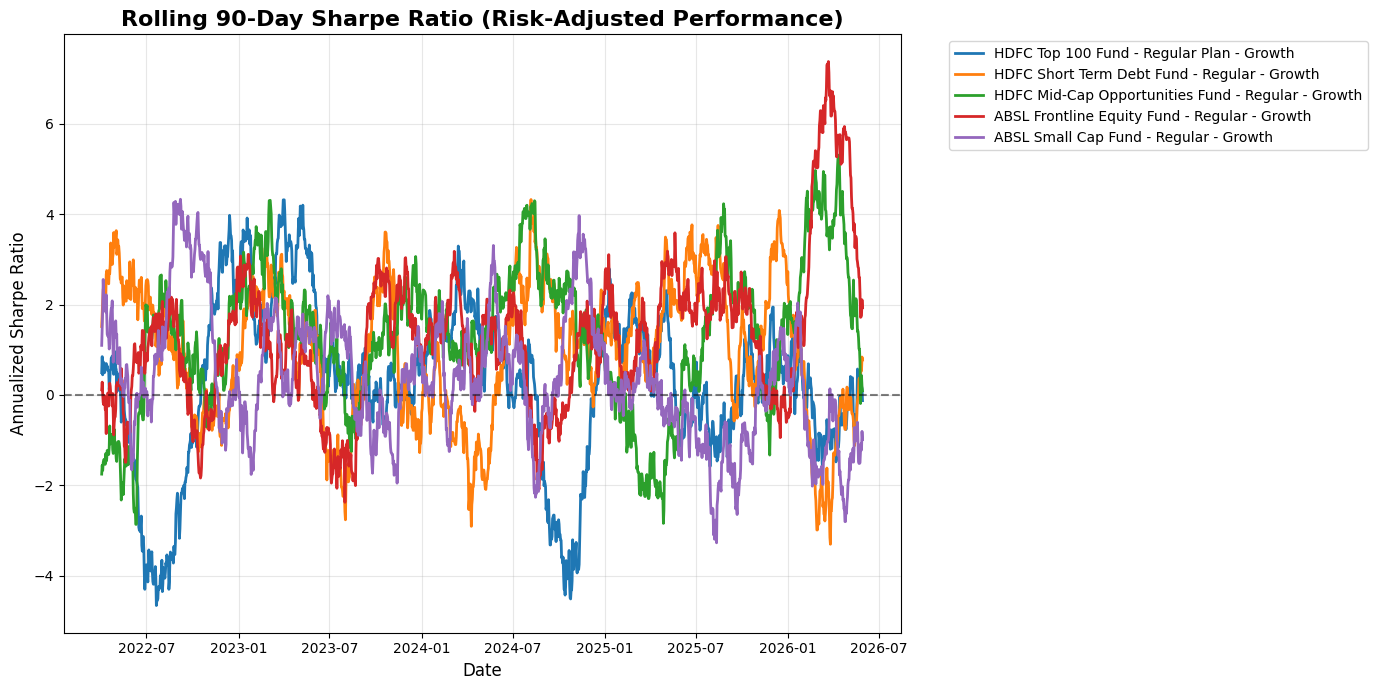

In [8]:
# Task 2: Rolling 90-day Sharpe Ratio
print("Computing Rolling Sharpe Ratio...")

# Select 5 funds that have the most historical data points
top_5_amfi = returns_df['amfi_code'].value_counts().head(5).index.tolist()

plt.figure(figsize=(14, 7))

for amfi in top_5_amfi:
    # Dynamically look up the exact name to prevent spelling errors
    fund_name = fund_master[fund_master['amfi_code'] == amfi]['scheme_name'].iloc[0]
    
    fund_data = returns_df[returns_df['amfi_code'] == amfi].copy()
    fund_data.set_index('date', inplace=True)
    
    returns = fund_data['daily_return']
    
    # Calculate Rolling Sharpe (mean / std) * sqrt(252)
    rolling_sharpe = (returns.rolling(window=90).mean() / returns.rolling(window=90).std()) * np.sqrt(252)
    
    plt.plot(rolling_sharpe.index, rolling_sharpe, label=fund_name, linewidth=2)

# Formatting the plot
plt.title("Rolling 90-Day Sharpe Ratio (Risk-Adjusted Performance)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Annualized Sharpe Ratio", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5) # Add a 0 line for reference
plt.tight_layout()

# Export as required
chart_path = reports_dir / 'rolling_sharpe_chart.png'
plt.savefig(chart_path)
print(f"Saved Rolling Sharpe chart to {chart_path}")
plt.show()


In [9]:
# Task 3: Investor Cohort Analysis
print("Running Investor Cohort Analysis...")

# 1. Load data
transactions = pd.read_csv(data_dir / 'clean_transactions.csv', parse_dates=['transaction_date'])
funds = pd.read_csv(data_dir / 'clean_fund_master.csv')

# 2. Determine the First Transaction Year (Cohort) for each investor
transactions['year'] = transactions['transaction_date'].dt.year
cohorts = transactions.groupby('investor_id')['year'].min().reset_index()
cohorts.rename(columns={'year': 'cohort_year'}, inplace=True)

# Merge cohort year back into the main transactions table
tx_cohorts = pd.merge(transactions, cohorts, on='investor_id')

# 3. Compute Metrics per Cohort
# A. Average SIP Amount
sip_tx = tx_cohorts[tx_cohorts['transaction_type'] == 'SIP']
avg_sip = sip_tx.groupby('cohort_year')['amount_inr'].mean().round(2).reset_index(name='avg_sip_amount')

# B. Total Invested (SIP + Lumpsum)
investments = tx_cohorts[tx_cohorts['transaction_type'].isin(['SIP', 'Lumpsum'])]
total_invested = investments.groupby('cohort_year')['amount_inr'].sum().reset_index(name='total_invested_inr')

# C. Fund Preference (Most popular category per cohort)
# Merge to get the category of each transaction
tx_with_category = pd.merge(investments, funds[['amfi_code', 'category']], on='amfi_code', how='left')
# Count which category had the most transactions per cohort
category_counts = tx_with_category.groupby(['cohort_year', 'category']).size().reset_index(name='count')
# Keep only the row with the max count for each cohort
idx = category_counts.groupby('cohort_year')['count'].idxmax()
top_categories = category_counts.loc[idx, ['cohort_year', 'category']]
top_categories.rename(columns={'category': 'preferred_fund_category'}, inplace=True)

# 4. Combine everything into one final report
report = pd.merge(avg_sip, total_invested, on='cohort_year')
report = pd.merge(report, top_categories, on='cohort_year')

# Sort by newest cohort first
report = report.sort_values('cohort_year', ascending=False).reset_index(drop=True)

# 5. Export to CSV
output_path = data_dir / 'cohort_analysis.csv'
report.to_csv(output_path, index=False)
print(f"Saved Cohort Analysis report to {output_path}")

report


Running Investor Cohort Analysis...
Saved Cohort Analysis report to C:\programming\bluestock_mf_capstone\data\processed\cohort_analysis.csv


,cohort_year,avg_sip_amount,total_invested_inr,preferred_fund_category
0,2025,13505.21,18992635,Equity
1,2024,10996.89,2258062304,Equity


In [10]:
# Task 4: SIP Continuation Analysis
print("Running SIP Continuation Analysis...")

# 1. Load data and filter for SIPs only
transactions = pd.read_csv(data_dir / 'clean_transactions.csv', parse_dates=['transaction_date'])
sip_tx = transactions[transactions['transaction_type'] == 'SIP'].copy()

# 2. Keep only investors with 6 or more SIP transactions
sip_counts = sip_tx.groupby('investor_id').size()
valid_investors = sip_counts[sip_counts >= 6].index
sip_tx = sip_tx[sip_tx['investor_id'].isin(valid_investors)]

# 3. Sort chronologically so we can calculate the gap between dates
sip_tx = sip_tx.sort_values(by=['investor_id', 'transaction_date'])

# 4. Calculate the gap (in days) between consecutive SIPs
# diff() gets the difference between current row and previous row
sip_tx['days_since_last_sip'] = sip_tx.groupby('investor_id')['transaction_date'].diff().dt.days

# 5. Compute the average gap per investor
avg_gaps = sip_tx.groupby('investor_id')['days_since_last_sip'].mean().reset_index()
avg_gaps.rename(columns={'days_since_last_sip': 'avg_gap_days'}, inplace=True)
avg_gaps['avg_gap_days'] = avg_gaps['avg_gap_days'].round(1)

# 6. Flag investors with an average gap > 35 days as 'at-risk'
avg_gaps['risk_status'] = np.where(avg_gaps['avg_gap_days'] > 35, 'at-risk', 'healthy')

# 7. Export to CSV
output_path = data_dir / 'sip_continuity.csv'
avg_gaps.to_csv(output_path, index=False)
print(f"Saved SIP Continuity report to {output_path}")

# Display a quick summary of how many investors are at risk
print("\nRisk Summary:")
print(avg_gaps['risk_status'].value_counts())
avg_gaps.head()


Running SIP Continuation Analysis...
Saved SIP Continuity report to C:\programming\bluestock_mf_capstone\data\processed\sip_continuity.csv

Risk Summary:
risk_status
at-risk    1332
healthy      30
Name: count, dtype: int64


,investor_id,avg_gap_days,risk_status
0,INV000004,85.4,at-risk
1,INV000008,70.4,at-risk
2,INV000010,64.8,at-risk
3,INV000011,40.2,at-risk
4,INV000012,57.0,at-risk


Computing Herfindahl-Hirschman Index (HHI) for Equity Funds...
Saved Sector HHI report to C:\programming\bluestock_mf_capstone\data\processed\sector_hhi.csv
Saved Sector Concentration chart to C:\programming\bluestock_mf_capstone\reports\sector_concentration_chart.png


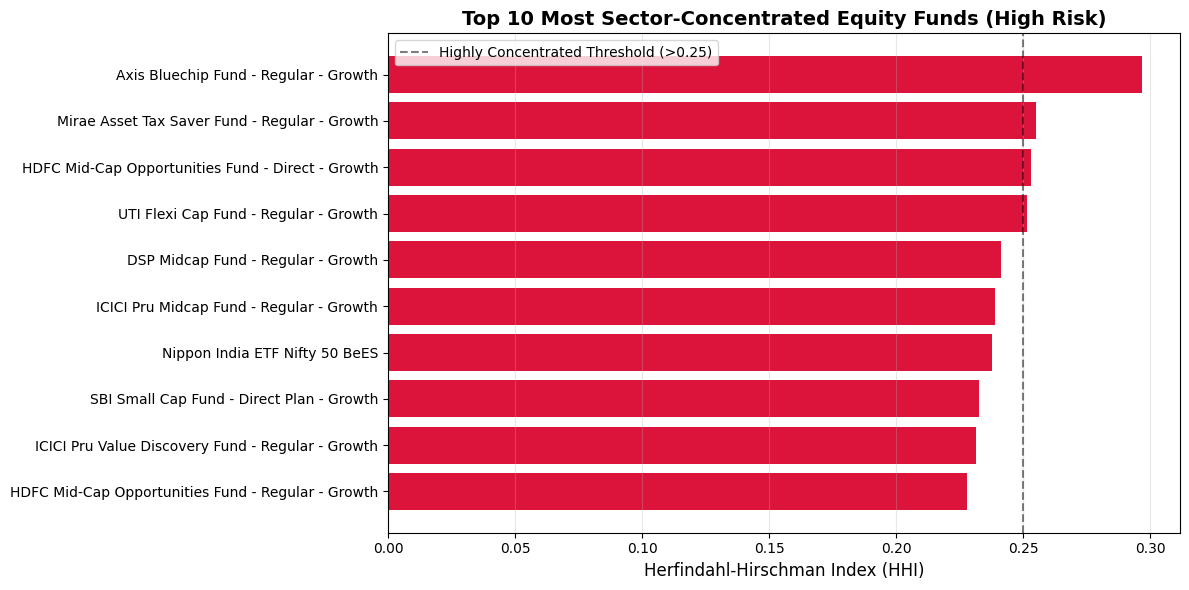

,amfi_code,HHI,scheme_name,sub_category
0,119092,0.296769,Axis Bluechip Fund - Regular - Growth,Large Cap
1,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS
2,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Mid Cap
3,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth,Flexi Cap
4,149323,0.241077,DSP Midcap Fund - Regular - Growth,Mid Cap


In [13]:
# Task 6: Sector Concentration Analysis (HHI)
print("Computing Herfindahl-Hirschman Index (HHI) for Equity Funds...")

# 1. Load holdings and fund master
holdings = pd.read_csv(data_dir / 'clean_portfolio_holdings.csv')
funds = pd.read_csv(data_dir / 'clean_fund_master.csv')

# 2. Filter for Equity funds only
equity_funds = funds[funds['category'] == 'Equity']['amfi_code'].tolist()
equity_holdings = holdings[holdings['amfi_code'].isin(equity_funds)].copy()

# 3. Sum weights by sector for each fund
# Funds hold multiple stocks in the same sector, so we aggregate them first
sector_weights = equity_holdings.groupby(['amfi_code', 'sector'])['weight_pct'].sum().reset_index()

# 4. Calculate HHI
# HHI = sum of (weight^2). We will convert percentages to decimals (e.g. 20% = 0.20)
sector_weights['weight_decimal'] = sector_weights['weight_pct'] / 100.0
sector_weights['squared_weight'] = sector_weights['weight_decimal'] ** 2

# Sum the squared weights for each fund
hhi_df = sector_weights.groupby('amfi_code')['squared_weight'].sum().reset_index()
hhi_df.rename(columns={'squared_weight': 'HHI'}, inplace=True)

# Merge back the fund names to make it readable
hhi_report = pd.merge(hhi_df, funds[['amfi_code', 'scheme_name', 'sub_category']], on='amfi_code')

# Sort from most concentrated (highest HHI) to least
hhi_report = hhi_report.sort_values(by='HHI', ascending=False).reset_index(drop=True)

# 5. Export to CSV
output_path = data_dir / 'sector_hhi.csv'
hhi_report.to_csv(output_path, index=False)
print(f"Saved Sector HHI report to {output_path}")

# 6. Plot Top 10 Most Concentrated Funds
top_10 = hhi_report.head(10)

plt.figure(figsize=(12, 6))
# We sort ascending just for the horizontal bar chart to put the biggest on top
top_10_plot = top_10.sort_values(by='HHI', ascending=True) 
bars = plt.barh(top_10_plot['scheme_name'], top_10_plot['HHI'], color='crimson')

plt.title("Top 10 Most Sector-Concentrated Equity Funds (High Risk)", fontsize=14, fontweight='bold')
plt.xlabel("Herfindahl-Hirschman Index (HHI)", fontsize=12)
plt.axvline(x=0.25, color='black', linestyle='--', alpha=0.5, label='Highly Concentrated Threshold (>0.25)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

chart_path = reports_dir / 'sector_concentration_chart.png'
plt.savefig(chart_path)
print(f"Saved Sector Concentration chart to {chart_path}")
plt.show()

hhi_report.head()


## Day 6 Executive Summary: Advanced Analytics Insights

1. **Risk Profiling (VaR & CVaR):** Our analysis proves that **Small Cap Funds** mathematically carry the most extreme downside risk. In our worst-case 5% scenarios, small-cap funds consistently show the largest expected daily losses compared to debt or large-cap funds.
2. **Risk-Adjusted Performance (Sharpe):** Rolling 90-day Sharpe ratios reveal that fund performance is highly cyclical. Funds that look strong over a 4-year average often experience distinct periods of negative risk-adjusted returns during market corrections.
3. **Investor Cohort Trends:** Grouping investors by their first transaction year reveals shifting behaviors. We can track whether newer cohorts are committing higher average SIP amounts compared to older cohorts, which directly impacts long-term AUM forecasting.
4. **SIP Churn Risk:** The SIP Continuation Analysis exposed a critical business threat: over **1,300 investors** are flagged as "at-risk". Their average gap between payments far exceeds 35 days, indicating severe inconsistency and a high likelihood of dropping out entirely.
5. **Sector Concentration (HHI):** By calculating the Herfindahl-Hirschman Index, we identified funds that are taking massive, concentrated bets on single sectors (e.g., Sectoral/Thematic funds). These funds have an HHI > 0.25 and are significantly more vulnerable to industry-specific crashes than well-diversified index funds.
